In [1]:
!python -m spacy download en_core_web_sm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 37.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import json
import spacy
import pandas as pd
import matplotlib.pyplot as plt
nlp_model = spacy.load("en_core_web_sm")

In [3]:
# Variables
valid_labels = ["PERSON", "NORP", "ORG", "GPE", "LOC", "DATE", "MONEY"]
json_file_path = 'data/ner_annotations.json'
data_file_path = 'data/tweets.xlsx'
student_id = 2

In [4]:
# transforming the manualy labeled tecoholic output json to list of tuples
def prepare_test_data(json_file_path):
    ground_truth = []  # list of list of tuples
    data_lst = []  # list of entities
    label_lst = []  # list of labels
    temp = []  # temporary list

    # Reading the JSON file
    with open(json_file_path) as f:
        data = json.load(f)

    # looping over all the sentences
    for sentence in range(len(data['annotations'])):
        # looping over all the entties in a given sentence
        for entity in data['annotations'][sentence][1]['entities']:
            start = entity[0]
            end = entity[1]
            label = entity[2]
            data_lst.append(data['annotations'][sentence][0][start:end])
            label_lst.append(label)
            # creating a list of tuples for each sentence
            # tuple format - (entity, label)
            temp = list(zip(data_lst, label_lst)) # creating list of tuples
        ground_truth.append(temp)
        data_lst = []
        label_lst = []
    return ground_truth
ground_truth = prepare_test_data(json_file_path)
print(f"Total number of sentences: {len(ground_truth)}")
print(f"first 2 sentence entities and labels after transformation: : {ground_truth[0:2]}")

Total number of sentences: 301
first 2 sentence entities and labels after transformation: : [[('Uganda', 'GPE'), ("Lord 's Resistance Army", 'ORG'), ('20 years', 'DATE')], [('Friday', 'DATE'), ('LRA', 'ORG')]]


In [5]:
tweets_df = pd.read_excel(data_file_path, sheet_name='Tweets')
resulting_text = " ".join(tweets_df['Sentence'].tolist())

In [6]:
# Creating a doc object
my_doc = nlp_model(resulting_text)

In [7]:
# NER using Spacy
def spacy_ner(valid_labels):
    predicted = []
    temp = []
    data_lst = []
    label_lst = []
    for sentence in my_doc.sents:
      # print(sentence)
        for entity in sentence.ents:
            temp = []
            data_lst.append(entity.text)
            label_lst.append(entity.label_)
            # creating a list of tuples for each sentence
            # tuple format - (entity, label)
            temp = list(zip(data_lst, label_lst))
        predicted.append(temp)
        predicted = [[(str(a), b) for a,b in lst if b in valid_labels] for lst in predicted]
        data_lst = []
        label_lst = []

    return predicted

# calling the function
predicted = spacy_ner(valid_labels)
print(f"Total number of sentences: {len(predicted)}")
print(f"first 2 sentence entities and labels after transformation: {predicted[0:2]}")

Total number of sentences: 301
first 2 sentence entities and labels after transformation: [[('Uganda', 'GPE'), ("the Lord 's Resistance Army", 'ORG'), ('more than 20 years', 'DATE')], [('Friday', 'DATE'), ('LRA', 'ORG')]]


In [8]:
# tp: both match
# fp: in pred but not in gt
# fn: in gt but not in pred

In [9]:
# Helper functions

# initialise confusion matrix
def intialise_confusion_matrix():
    confusion_matrix = {
          "PERSON": {"tp": 0, "fp": 0, "fn": 0},
          "NORP":   {"tp": 0, "fp": 0, "fn": 0},
          "ORG":    {"tp": 0, "fp": 0, "fn": 0},
          "GPE":    {"tp": 0, "fp": 0, "fn": 0},
          "LOC":    {"tp": 0, "fp": 0, "fn": 0},
          "DATE":   {"tp": 0, "fp": 0, "fn": 0},
          "MONEY":  {"tp": 0, "fp": 0, "fn": 0},
      }
    return confusion_matrix

# initialise accuracy metrics
def intialise_accuracy_metrics():
     # initialising accuracy metrics
    accuracy_metrics = {"precision": {"PERSON" : 0, "NORP" : 0, "ORG" : 0, "GPE" : 0, "LOC" : 0, "DATE" : 0, "MONEY" : 0},
                      "recall": {"PERSON" : 0, "NORP" : 0, "ORG" : 0, "GPE" : 0, "LOC" : 0, "DATE" : 0, "MONEY" : 0},
                      "f1_score": {"PERSON" : 0, "NORP" : 0, "ORG" : 0, "GPE" : 0, "LOC" : 0, "DATE" : 0, "MONEY" : 0}
                      }
    return accuracy_metrics


# prepare data for each label
def prepare_data(ground_truth, predicted, label):
    ground_truth = [[(entity, tag) for entity,tag in lst if tag == label] for lst in ground_truth]
    predicted = [[(entity, tag) for entity,tag in lst if tag == label] for lst in predicted]

    return ground_truth, predicted

# EXACT MATCH
def calculate_confusion_matrix_em(ground_truth, predicted, label, metrics_dict):
    for gt_sentence, pred_sentence in zip(ground_truth, predicted):
        pred_copy = pred_sentence.copy()

        for entity, label in gt_sentence:
            # checking if (entity, label) present in prediction
            if (entity, label) in pred_copy:
                metrics_dict[label]['tp'] += 1
                # dropping the instance of matched (entity, label) from the prediction list
                pred_copy.remove((entity, label))
            else:
                # in gt but not in pred
                metrics_dict[label]['fn'] += 1
        # if pred but not in gt
        metrics_dict[label]['fp'] += len(pred_copy)

    return metrics_dict

# partial match
def calculate_confusion_matrix_pm(ground_truth, predicted, label, metrics_dict):
    for gt_sentence, pred_sentence in zip(ground_truth, predicted):
        pred_copy = pred_sentence.copy()

        for entity_gt, label_gt in gt_sentence:
            flag = False
            for entity_pred, label_pred in pred_copy:

                # checking if gt's (substring of 'entity', 'label') present in prediction and pred's (substring of 'entity', 'label') present in gt
                if ((entity_gt in entity_pred or entity_pred in entity_gt) and label_gt == label_pred):
                    metrics_dict[label]['tp'] += 1
                    pred_copy.remove((entity_pred, label_pred))
                    flag = True
                    break
            if flag==False:
                # in gt but not in pred
                metrics_dict[label]['fn'] += 1
        # in pred but not in gt
        metrics_dict[label]['fp'] += len(pred_copy)

    return metrics_dict

# calculate metrics for all the valid labels
def calculate_confusion_matrix(ground_truth, predicted, valid_labels):
    metrics_dict_em = intialise_confusion_matrix()
    metrics_dict_pm = intialise_confusion_matrix()
    for label in valid_labels:
        gt, pred = prepare_data(ground_truth, predicted, label)
        # print(f'gt:{gt}\n pred:{pred}')
        confusion_matrix_em = calculate_confusion_matrix_em(gt, pred, label, metrics_dict_em)
        confusion_matrix_pm = calculate_confusion_matrix_pm(gt, pred, label, metrics_dict_pm)


    return confusion_matrix_em, confusion_matrix_pm

def calculate_accuracy_metrics(confusion_matrix):
    accuracy_metrics = intialise_accuracy_metrics()
    for label in valid_labels:
        accuracy_metrics['precision'][label] = confusion_matrix[label]['tp']/(confusion_matrix[label]['tp']+confusion_matrix[label]['fp']) if (confusion_matrix[label]['tp']+confusion_matrix[label]['fp']) > 0 else 0
        accuracy_metrics['recall'][label] = confusion_matrix[label]['tp']/(confusion_matrix[label]['tp']+confusion_matrix[label]['fn']) if (confusion_matrix[label]['tp']+confusion_matrix[label]['fp']) > 0 else 0
        accuracy_metrics['f1_score'][label] = (2 * accuracy_metrics['precision'][label] * accuracy_metrics['recall'][label])/(accuracy_metrics['precision'][label] + accuracy_metrics['recall'][label]) if (accuracy_metrics['precision'][label] + accuracy_metrics['recall'][label]) > 0 else 0

    return accuracy_metrics

def plot_accuracy_metrics(confusion_matrix, accuracy_metrics, em_pm):
    # Convert the dictionary to a pandas DataFrame
    confusion_df = pd.DataFrame(confusion_matrix)

    # print the DataFrame
    print(f'\nConfusion matrix for {em_pm}:')
    print(confusion_df.to_string(index=True, float_format="%.2f"))


    # Convert the dictionary to a pandas DataFrame
    print(f'\nAccuracy metrics for {em_pm}:')
    df = pd.DataFrame(accuracy_metrics)

    # print the DataFrame
    print(df.to_string(index=True, float_format="%.2f"))

    # Plotting the metrics
    df.plot(kind='bar', figsize=(10, 6))
    plt.title(f'Precision, Recall, and F1-Score by Entity Type for {em_pm}')
    plt.ylabel('Score')
    plt.xlabel('Entity Type')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title="Metrics")
    plt.tight_layout()

    # Show the plot
    plt.show()



Confusion matrix for Exact Match:
    PERSON  NORP  ORG  GPE  LOC  DATE  MONEY
tp      65   116   33  175   10   108      2
fp      49    41   80   52   16    76      0
fn      62    51   48   66   27    56      0

Accuracy metrics for Exact Match:
        precision  recall  f1_score
PERSON       0.57    0.51      0.54
NORP         0.74    0.69      0.72
ORG          0.29    0.41      0.34
GPE          0.77    0.73      0.75
LOC          0.38    0.27      0.32
DATE         0.59    0.66      0.62
MONEY        1.00    1.00      1.00


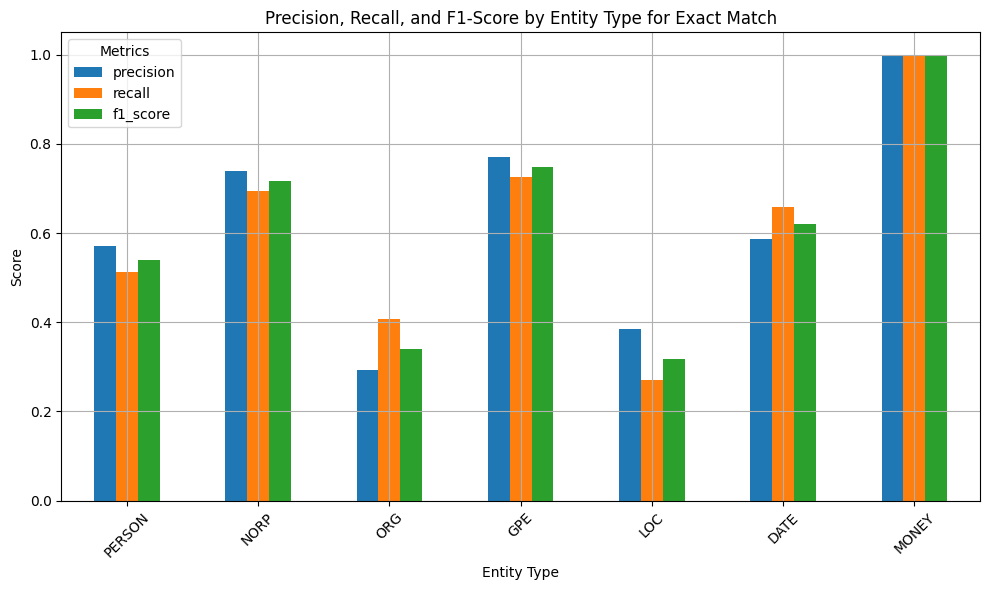

In [10]:
def main():
    # prepare test data
    ground_truth = prepare_test_data(json_file_path)

    # prepare data from spacy large model for the valid labels ["PERSON", "NORP", "ORG", "GPE", "LOC", "DATE", "MONEY"]
    predicted = spacy_ner(valid_labels)

    # calculate confusion matrix
    confusion_matrix_em, confusion_matrix_pm = calculate_confusion_matrix(ground_truth, predicted, valid_labels)

    accuracy_metrics_em = calculate_accuracy_metrics(confusion_matrix_em)
    accuracy_metrics_pm = calculate_accuracy_metrics(confusion_matrix_pm)

    # visualize the results
    # for partial match
    # plot_accuracy_metrics(confusion_matrix_pm, accuracy_metrics_pm, 'Partial Match')

    # for exact match
    # uncomment to see the results for exact match
    plot_accuracy_metrics(confusion_matrix_em, accuracy_metrics_em, 'Exact Match')

if __name__ == "__main__":
    main()
